## Definiendo la variable objetivo de churn

Antes de cualquier prueba estadística necesito una definición operacional de
churn -- sin esto no hay grupos que comparar. Reviso primero si notifications
tiene alguna categoría explícita de cierre de cuenta (más confiable, evento
observado) antes de recurrir a una definición basada en recencia de
transacciones (más común en la industria, pero requiere elegir un umbral de
días de inactividad que hay que justificar, no adivinar).

In [1]:
import pandas as pd

clean_users_df = pd.read_parquet("../data/users_clean.parquet")
clean_devices_df = pd.read_parquet("../data/devices_clean.parquet")
clean_notifications_df = pd.read_parquet("../data/notifications_clean.parquet")
clean_transactions_df = pd.read_parquet("../data/transactions_clean.parquet")

print(clean_users_df.shape, clean_devices_df.shape, clean_notifications_df.shape, clean_transactions_df.shape)

(19430, 11) (19430, 2) (121813, 5) (2681355, 13)


In [2]:
# 1. ¿Hay una categoría explícita de cierre/churn en notifications.reason?
print(clean_notifications_df["reason"].value_counts())

reason
REENGAGEMENT_ACTIVE_FUNDS               35844
FIFTH_PAYMENT_PROMO                     23743
NO_INITIAL_CARD_USE                     11221
NO_INITIAL_CARD_ORDER                   11136
METAL_GAME_START                         8373
LOST_CARD_ORDER                          6146
NO_INITIAL_FREE_PROMOPAGE_CARD_ORDER     5459
JOINING_ANNIVERSARY                      4158
MADE_MONEY_REQUEST_NOT_SPLIT_BILL        3506
ONBOARDING_TIPS_ACTIVATED_USERS          3145
ENGAGEMENT_SPLIT_BILL_RESTAURANT         2298
BLACK_FRIDAY                             2109
METAL_RESERVE_PLAN                       1233
PREMIUM_ENGAGEMENT_INACTIVE_CARD         1124
WELCOME_HOME                              950
PUMPKIN_PAYMENT_NOTIFICATION              690
PREMIUM_ENGAGEMENT_FEES_SAVED             678
Name: count, dtype: int64


In [3]:
REFERENCE_DATE = pd.Timestamp("2026-07-01")  # misma fecha fija que en base_clean

last_transaction = (
    clean_transactions_df
    .groupby("user_id")["created_date"]
    .max()
    .reset_index()
    .rename(columns={"created_date": "last_transaction_date"})
)

last_transaction["days_since_last_txn"] = (
    REFERENCE_DATE - last_transaction["last_transaction_date"].dt.tz_localize(None)
).dt.days

print(last_transaction["days_since_last_txn"].describe())

users_with_txn = set(last_transaction["user_id"])
users_total = set(clean_users_df["user_id"])
print(f"\nUsuarios sin ninguna transacción: {len(users_total - users_with_txn)} de {len(users_total)}")

count    18764.000000
mean      2672.647410
std        101.487744
min       2602.000000
25%       2609.000000
50%       2620.000000
75%       2696.000000
max       3100.000000
Name: days_since_last_txn, dtype: float64

Usuarios sin ninguna transacción: 666 de 19430


## Corrigiendo REFERENCE_DATE con la fecha real del dataset

Al calcular días desde la última transacción, encontré que TODOS los
usuarios muestran miles de días de inactividad -- una señal de que mi
REFERENCE_DATE (que había fijado arbitrariamente en 2026-07-01) no tiene
relación con el periodo real de los datos. Este dataset es un snapshot
histórico que termina en algún punto de 2018-2019, no datos en vivo hasta
hoy. Corrijo REFERENCE_DATE para que sea un día después de la última
transacción REAL observada en el dataset -- así "días de inactividad" mide
algo con sentido dentro de la ventana de datos que en verdad tengo, en vez
de comparar contra el calendario real de hoy.

In [4]:
# Fecha real máxima observada en el dataset
max_txn_date = clean_transactions_df["created_date"].max()
min_txn_date = clean_transactions_df["created_date"].min()
print(f"Rango real de transactions: {min_txn_date} a {max_txn_date}")

max_notif_date = clean_notifications_df["created_date"].max()
print(f"Última notificación: {max_notif_date}")

max_signup_date = clean_users_df["created_date"].max() if "created_date" in clean_users_df.columns else clean_users_df["signup_date"].max()
print(f"Último signup: {max_signup_date}")

Rango real de transactions: 2018-01-01 08:51:10.248709+00:00 a 2019-05-16 18:22:16.959896+00:00
Última notificación: 2019-05-12 17:12:14.132130+00:00
Último signup: 2019-01-03 07:34:36.638892+00:00


## REFERENCE_DATE corregida

Fijo REFERENCE_DATE un día después de la última transacción observada
(2019-05-16), no en la fecha de hoy. Esto es consistente con la razón
original por la que decidí usar una fecha fija desde el inicio del
proyecto: quiero que "días de inactividad" se mida contra el final real
de la ventana de datos disponible, no contra un punto arbitrario del
calendario actual que no tiene relación con cuándo se generaron los datos.

In [5]:
REFERENCE_DATE = pd.Timestamp("2019-05-17")

last_transaction["days_since_last_txn"] = (
    REFERENCE_DATE - last_transaction["last_transaction_date"].dt.tz_localize(None)
).dt.days

print(last_transaction["days_since_last_txn"].describe())
print("\nPercentiles:")
print(last_transaction["days_since_last_txn"].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

count    18764.000000
mean        70.647410
std        101.487744
min          0.000000
25%          7.000000
50%         18.000000
75%         94.000000
max        498.000000
Name: days_since_last_txn, dtype: float64

Percentiles:
0.10      5.00
0.25      7.00
0.50     18.00
0.75     94.00
0.90    230.00
0.95    308.00
0.99    428.37
Name: days_since_last_txn, dtype: float64


count    18739.000000
mean        63.885479
std         98.656183
min          0.000000
25%          2.000000
50%         13.000000
75%         88.000000
max        482.000000
Name: days_since_last_txn, dtype: float64

Percentiles:
0.10      0.0
0.25      2.0
0.50     13.0
0.75     88.0
0.90    217.0
0.95    294.0
0.99    414.0
Name: days_since_last_txn, dtype: float64


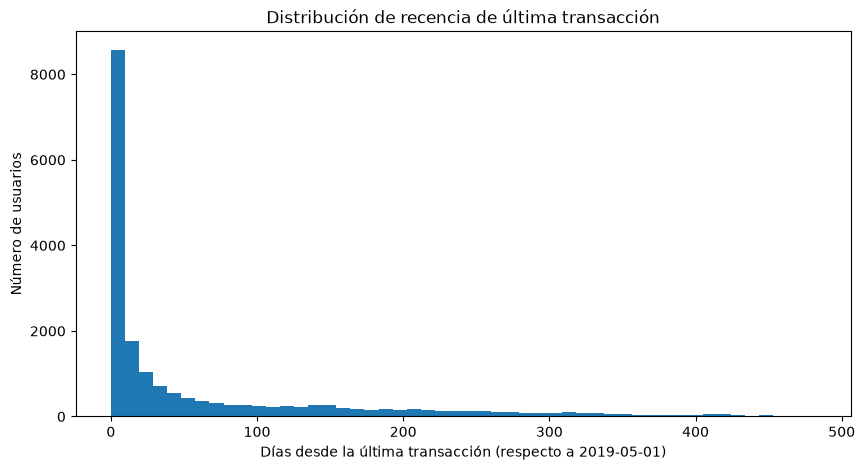

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

clean_users_df = pd.read_parquet("../data/users_clean.parquet")
clean_transactions_df = pd.read_parquet("../data/transactions_clean.parquet")

REFERENCE_DATE = pd.Timestamp("2019-05-01")

txn_for_recency = clean_transactions_df[
    clean_transactions_df["created_date"].dt.tz_localize(None) < REFERENCE_DATE
]

last_transaction = (
    txn_for_recency
    .groupby("user_id")["created_date"]
    .max()
    .reset_index()
    .rename(columns={"created_date": "last_transaction_date"})
)

last_transaction["days_since_last_txn"] = (
    REFERENCE_DATE - last_transaction["last_transaction_date"].dt.tz_localize(None)
).dt.days

print(last_transaction["days_since_last_txn"].describe())
print("\nPercentiles:")
print(last_transaction["days_since_last_txn"].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

plt.figure(figsize=(10, 5))
plt.hist(last_transaction["days_since_last_txn"], bins=50)
plt.xlabel("Días desde la última transacción (respecto a 2019-05-01)")
plt.ylabel("Número de usuarios")
plt.title("Distribución de recencia de última transacción")
plt.show()

## Eligiendo el umbral de churn: 90 días

La distribución de recencia no es bimodal -- es una cola larga sin un valle
natural que separe dos grupos. Sin ese punto obvio, ancло el corte en algo
defendible por contexto de negocio: 90 días (un trimestre) sin ninguna
transacción es un umbral estándar en fintech para considerar a un usuario
inactivo, y coincide de forma razonable con mi percentil 75 (88 días) --
es decir, con este corte cerca de una cuarta parte de la base se
clasificaría como churned, una tasa plausible para un neobank en su primer
año y medio de vida. 

In [7]:
users_no_txn = clean_users_df[~clean_users_df["user_id"].isin(last_transaction["user_id"])]
print(users_no_txn["created_date"].describe())
print(users_no_txn["created_date"].min(), "a", users_no_txn["created_date"].max())

count                                 691
mean     2018-08-31 16:09:37.374670+00:00
min      2018-01-03 17:28:09.209847+00:00
25%      2018-06-19 07:15:38.449342+00:00
50%      2018-09-27 19:41:42.388011+00:00
75%      2018-11-21 16:28:51.751797+00:00
max      2019-01-02 15:43:57.780575+00:00
Name: created_date, dtype: object
2018-01-03 17:28:09.209847+00:00 a 2019-01-02 15:43:57.780575+00:00


## Construyendo churn_flag

Antes de marcar a los 691 usuarios sin transacciones como churned, verifiqué
que ninguno tiene una excusa de "recién se registró" -- incluso el signup
más reciente de este grupo lleva 119 días sin transaccionar, muy por encima
de mi umbral de 90 días. Esto descarta la censura por signup reciente como
explicación, y confirma que es un abandono real, no falta de tiempo.

Construyo churn_flag combinando dos casos: usuarios con al menos una
transacción, marcados churned si su recencia supera 90 días; y usuarios sin
ninguna transacción, marcados churned directamente (ya que todos superan el
umbral de gracia, como acabo de confirmar).

In [8]:
import numpy as np

In [9]:
CHURN_THRESHOLD_DAYS = 90

# Caso 1: usuarios con al menos una transacción
churn_with_txn = last_transaction[["user_id", "days_since_last_txn"]].copy()
churn_with_txn["churn_flag"] = churn_with_txn["days_since_last_txn"] > CHURN_THRESHOLD_DAYS

# Caso 2: usuarios sin ninguna transacción -> churned directo (confirmado arriba)
users_no_txn_ids = clean_users_df.loc[
    ~clean_users_df["user_id"].isin(last_transaction["user_id"]), "user_id"
]
churn_no_txn = pd.DataFrame({
    "user_id": users_no_txn_ids,
    "days_since_last_txn": np.nan,  # no aplica, nunca transaccionó
    "churn_flag": True,
})

churn_df = pd.concat([churn_with_txn, churn_no_txn], ignore_index=True)

# Merge con users para tener todo en un solo DataFrame de análisis
users_with_churn = clean_users_df.merge(churn_df, on="user_id", how="left")

print(f"Total usuarios: {len(users_with_churn)}")
print(f"Churn rate: {users_with_churn['churn_flag'].mean():.2%}")
print(users_with_churn["churn_flag"].value_counts())

Total usuarios: 19430
Churn rate: 27.29%
churn_flag
False    14128
True      5302
Name: count, dtype: int64


## Pruebas estadísticas: Chi-square y Mann-Whitney U con effect size

Sigo el enfoque que definí desde el inicio del proyecto: el p-value me dice
si una diferencia es estadísticamente detectable, pero con casi 19,430
usuarios, hasta diferencias triviales van a salir "significativas" -- lo que
realmente me importa es el tamaño del efecto, que me dice si la diferencia
es lo bastante grande como para actuar sobre ella.

Para variables categóricas (plan, country, device_brand) uso Chi-square de
independencia + Cramér's V como effect size (0.1 = pequeño, 0.3 = mediano,
0.5 = grande, según las convenciones de Cohen).

Para variables continuas (age, num_contacts) uso Mann-Whitney U en vez de
un t-test, porque no quiero asumir normalidad de entrada -- y como effect
size uso la correlación rank-biserial (equivalente no-paramétrico de la d
de Cohen), no solo el p-value de U.

Empiezo con plan, country, device_brand y age, num_contacts -- en cuanto
tengamos las agregaciones de transactions por usuario, agrego total gastado
y frecuencia de transacciones a esta misma batería de pruebas.

In [10]:
from scipy.stats import chi2_contingency, mannwhitneyu
import numpy as np

# ---------------------------------------------------------------------
# Merge con devices para tener device_brand disponible en el análisis
# ---------------------------------------------------------------------
analysis_df = users_with_churn.merge(clean_devices_df, on="user_id", how="left")


def cramers_v(contingency_table):
    """Effect size para Chi-square: 0.1 pequeño, 0.3 mediano, 0.5 grande (Cohen)."""
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    v = np.sqrt((chi2 / n) / min_dim)
    return chi2, p, v


def rank_biserial(group_a, group_b):
    """Effect size para Mann-Whitney U: equivalente no-paramétrico de d de Cohen."""
    u_stat, p = mannwhitneyu(group_a, group_b, alternative="two-sided")
    n1, n2 = len(group_a), len(group_b)
    r = 1 - (2 * u_stat) / (n1 * n2)
    return u_stat, p, r


# ---------------------------------------------------------------------
# Chi-square: variables categóricas vs churn_flag
# ---------------------------------------------------------------------
print("=" * 60)
print("CHI-SQUARE (categóricas)")
print("=" * 60)

for col in ["plan", "country", "device_brand"]:
    table = pd.crosstab(analysis_df[col], analysis_df["churn_flag"])
    chi2, p, v = cramers_v(table)
    print(f"\n{col}: chi2={chi2:.2f}, p={p:.4f}, Cramér's V={v:.4f}")


# ---------------------------------------------------------------------
# Mann-Whitney U: variables continuas vs churn_flag
# ---------------------------------------------------------------------
print("\n" + "=" * 60)
print("MANN-WHITNEY U (continuas)")
print("=" * 60)

for col in ["age", "num_contacts"]:
    churned = analysis_df.loc[analysis_df["churn_flag"], col].dropna()
    active = analysis_df.loc[~analysis_df["churn_flag"], col].dropna()
    u_stat, p, r = rank_biserial(churned, active)
    print(f"\n{col}: U={u_stat:.1f}, p={p:.4f}, rank-biserial r={r:.4f}")
    print(f"  Mediana churned: {churned.median():.2f} | Mediana activos: {active.median():.2f}")

CHI-SQUARE (categóricas)

plan: chi2=508.92, p=0.0000, Cramér's V=0.1618

country: chi2=644.44, p=0.0000, Cramér's V=0.1821

device_brand: chi2=31.98, p=0.0000, Cramér's V=0.0406

MANN-WHITNEY U (continuas)

age: U=39401688.0, p=0.0000, rank-biserial r=-0.0520
  Mediana churned: 41.00 | Mediana activos: 39.00

num_contacts: U=19766610.5, p=0.0000, rank-biserial r=0.4722
  Mediana churned: 0.00 | Mediana activos: 9.00


## Profundizando en plan y country con residuos estandarizados

Cramér's V me da un resumen global, pero con country (41 categorías) puede
esconder que solo un puñado de países está impulsando la asociación mientras
el resto no aporta nada. Calculo los residuos estandarizados de la tabla de
contingencia para identificar específicamente qué categorías de plan y de
country se desvían más de lo esperado bajo independencia -- eso es más
accionable que solo saber que "hay una asociación" en general.

In [11]:
def standardized_residuals(contingency_table):
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    residuals = (contingency_table - expected) / np.sqrt(expected)
    return residuals


print("=" * 60)
print("Residuos estandarizados: plan x churn_flag")
print("(|residuo| > 2 se considera una desviación notable)")
print("=" * 60)
plan_table = pd.crosstab(analysis_df["plan"], analysis_df["churn_flag"])
print(standardized_residuals(plan_table))

print("\n" + "=" * 60)
print("Tasa de churn por plan (para interpretar dirección)")
print("=" * 60)
print(analysis_df.groupby("plan")["churn_flag"].agg(["mean", "count"]).sort_values("mean", ascending=False))

print("\n" + "=" * 60)
print("Top 10 países por |residuo estandarizado|")
print("=" * 60)
country_table = pd.crosstab(analysis_df["country"], analysis_df["churn_flag"])
country_residuals = standardized_residuals(country_table)
# Ordeno por el residuo de la columna True (churned), en valor absoluto
top_countries = country_residuals[True].abs().sort_values(ascending=False).head(10).index
print(country_residuals.loc[top_countries])

print("\nTasa de churn en esos países (para interpretar dirección):")
print(analysis_df[analysis_df["country"].isin(top_countries)]
      .groupby("country")["churn_flag"].agg(["mean", "count"]).sort_values("mean", ascending=False))

Residuos estandarizados: plan x churn_flag
(|residuo| > 2 se considera una desviación notable)
churn_flag        False      True 
plan                              
METAL          7.049299 -11.507115
METAL_FREE     1.946542  -3.177491
PREMIUM        8.494666 -13.866498
PREMIUM_FREE   0.640019  -1.044753
PREMIUM_OFFER  1.600048  -2.611881
STANDARD      -3.203379   5.229123

Tasa de churn por plan (para interpretar dirección)
                   mean  count
plan                          
STANDARD       0.293241  17992
PREMIUM        0.026590    865
METAL          0.005917    507
METAL_FREE     0.000000     37
PREMIUM_FREE   0.000000      4
PREMIUM_OFFER  0.000000     25

Top 10 países por |residuo estandarizado|
churn_flag     False      True 
country                        
IE          6.269543 -10.234257
MT          5.487380  -8.957473
GB         -5.368467   8.763363
RO          5.280686  -8.620070
GR         -3.058955   4.993368
PL          2.594855  -4.235782
NL         -2.357682   3.

## Interpretando plan y country: cuidado con causalidad y muestras chicas

El hallazgo de plan es el más fuerte del análisis hasta ahora, pero anoto
una limitación importante: es muy probable que sea autoselección (usuarios
ya comprometidos eligen pagar) y no que el plan premium cause la retención.
Lo dejo marcado como variable de segmentación fuerte para el dashboard y la
matriz de riesgo, pero no como palanca de intervención directa sin más
evidencia causal.

Para country, trato con cautela los residuos de países con muestra chica
(Gibraltar, n=44) -- un solo usuario que cambia de status puede mover
mucho el porcentaje ahí. Me quedo con el patrón en países de volumen
confiable (GB, ES, DE, NL, GR con churn alto; IE, MT con churn bajo) como
la señal real.

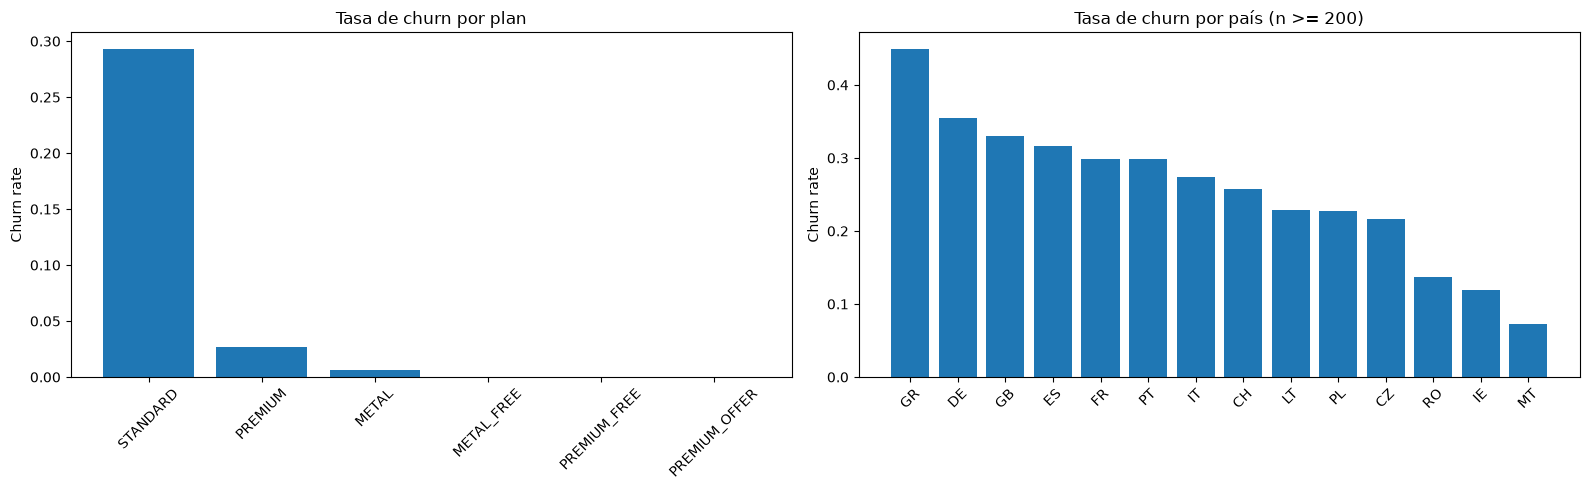

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plan_churn = analysis_df.groupby("plan")["churn_flag"].mean().sort_values(ascending=False)
axes[0].bar(plan_churn.index, plan_churn.values)
axes[0].set_title("Tasa de churn por plan")
axes[0].set_ylabel("Churn rate")
axes[0].tick_params(axis="x", rotation=45)

country_stats = analysis_df.groupby("country")["churn_flag"].agg(["mean", "count"])
country_reliable = country_stats[country_stats["count"] >= 200].sort_values("mean", ascending=False)
axes[1].bar(country_reliable.index, country_reliable["mean"])
axes[1].set_title("Tasa de churn por país (n >= 200)")
axes[1].set_ylabel("Churn rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Agregando transactions a nivel usuario para las pruebas

Calculo las métricas usando solo transacciones antes de REFERENCE_DATE
(2019-05-01), la misma ventana que usé para churn_flag -- así evito
mezclar el sesgo del mes parcial de mayo en estas agregaciones también.

Uso active_days como número de días distintos con actividad (no el rango
de fechas entre primera y última transacción), porque me interesa medir
qué tan seguido usa la app el usuario, no solo cuánto tiempo lleva de
"antigüedad" con al menos una transacción en cada extremo.

declined_rate mide fricción: qué proporción de los intentos de transacción
de un usuario terminan rechazados. Mi hipótesis es que alta fricción
(tarjeta rechazada seguido, fondos insuficientes) podría predecir abandono,
más allá de cuánto gasta en total.

Estas métricas solo existen para usuarios con al menos 1 transacción --
los 691 sin ninguna quedan con NaN aquí (ya sabemos que son churn por
definición, así que no pierdo esa señal, solo no aplica esta variable
específica para ellos).

In [13]:
txn_agg = (
    txn_for_recency
    .assign(is_declined=lambda d: d["transactions_state"] == "DECLINED",
            txn_date=lambda d: d["created_date"].dt.date)
    .groupby("user_id")
    .agg(
        total_amount=("amount_usd", "sum"),
        num_transactions=("transaction_id", "count"),
        avg_transaction_amount=("amount_usd", "mean"),
        active_days=("txn_date", "nunique"),
        declined_rate=("is_declined", "mean"),
    )
    .reset_index()
)

analysis_df = analysis_df.merge(txn_agg, on="user_id", how="left")

print(analysis_df[["total_amount", "num_transactions", "avg_transaction_amount",
                     "active_days", "declined_rate"]].describe())

       total_amount  num_transactions  avg_transaction_amount   active_days  \
count  1.873900e+04      18739.000000            18739.000000  18739.000000   
mean   1.183868e+04        137.142804              117.264442     45.160628   
std    7.175115e+04        231.680536             1245.398885     54.790503   
min    1.000000e-02          1.000000                0.010000      1.000000   
25%    4.375150e+02         16.000000               14.980014      8.000000   
50%    2.414380e+03         57.000000               32.486783     25.000000   
75%    7.814680e+03        155.000000               65.158778     62.000000   
max    3.207774e+06       4842.000000            95523.856667    453.000000   

       declined_rate  
count   18739.000000  
mean        0.070780  
std         0.101310  
min         0.000000  
25%         0.000000  
50%         0.039216  
75%         0.093023  
max         1.000000  


In [14]:
print("=" * 60)
print("MANN-WHITNEY U (transacciones agregadas)")
print("=" * 60)

for col in ["total_amount", "num_transactions", "avg_transaction_amount",
            "active_days", "declined_rate"]:
    churned = analysis_df.loc[analysis_df["churn_flag"], col].dropna()
    active = analysis_df.loc[~analysis_df["churn_flag"], col].dropna()
    u_stat, p, r = rank_biserial(churned, active)
    print(f"\n{col}: U={u_stat:.1f}, p={p:.4f}, rank-biserial r={r:.4f}")
    print(f"  Mediana churned: {churned.median():.2f} | Mediana activos: {active.median():.2f}")

MANN-WHITNEY U (transacciones agregadas)

total_amount: U=11985616.5, p=0.0000, rank-biserial r=0.6320
  Mediana churned: 166.43 | Mediana activos: 3750.27

num_transactions: U=8889199.5, p=0.0000, rank-biserial r=0.7271
  Mediana churned: 8.00 | Mediana activos: 86.00

avg_transaction_amount: U=23155759.5, p=0.0000, rank-biserial r=0.2891
  Mediana churned: 19.10 | Mediana activos: 35.72

active_days: U=7910279.0, p=0.0000, rank-biserial r=0.7571
  Mediana churned: 4.00 | Mediana activos: 37.00

declined_rate: U=21838025.5, p=0.0000, rank-biserial r=0.3295
  Mediana churned: 0.00 | Mediana activos: 0.05


## Alerta de data leakage en las métricas de transacciones

Encontré que num_transactions, active_days y total_amount tienen effect
sizes enormes (r > 0.6), pero sospecho que es circularidad: los calculé
sobre la misma ventana completa que usé para definir churn_flag por
recencia, así que un usuario que churneó temprano mecánicamente tuvo menos
tiempo para acumular transacciones -- no es una señal predictiva real, es
casi la definición de churn repetida.

Para el modelo de Random Forest, voy a recalcular estas métricas usando
solo una ventana de observación temprana (ej. los primeros 60-90 días desde
el signup de cada usuario), y voy a medir churn en el periodo posterior --
así el modelo predice con información que existía ANTES del desenlace, no
información que ya contiene el desenlace mismo.

También noto que declined_rate salió en dirección opuesta a mi hipótesis
de fricción: los usuarios activos tienen declined_rate más alto que los
churned, probablemente porque transaccionar más da más oportunidades de
que algo se rechace -- un artefacto de volumen, no evidencia de que la
fricción cause abandono. Documento la hipótesis como no confirmada en vez
de forzar la narrativa original.

## Verificando si existe estacionalidad real en los datos

Antes de rediseñar el umbral de churn por la hipótesis de uso estacional
(vacaciones), reviso si el patrón realmente aparece en los datos. Con solo
16 meses de historia (enero 2018 a abril 2019), no alcanzo a ver un ciclo
completo de "dos veranos" para nadie, pero sí puedo revisar si hay un pico
de actividad agregada en meses de verano/invierno que sugiera el patrón, y
cuantificar cuántos usuarios muestran un hueco largo seguido de una vuelta
a la actividad dentro de la ventana que sí tengo.

/tmp/ipykernel_23044/1603638413.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda d: d["created_date"].dt.to_period("M"))


month
2018-01      6153
2018-02     14974
2018-03     32969
2018-04     43543
2018-05     72156
2018-06     90075
2018-07    117597
2018-08    149441
2018-09    171185
2018-10    199071
2018-11    223508
2018-12    254375
2019-01    267402
2019-02    283434
2019-03    326315
2019-04    317721
2019-05    111436
Freq: M, dtype: int64


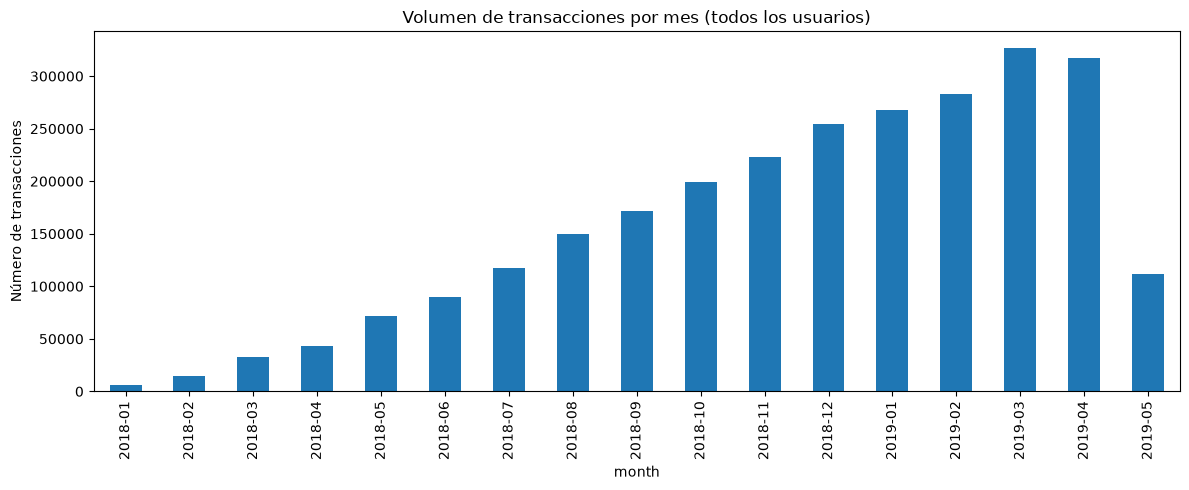

In [15]:
# 1. ¿Hay estacionalidad visible en el volumen agregado de transacciones?
monthly_volume = (
    clean_transactions_df
    .assign(month=lambda d: d["created_date"].dt.to_period("M"))
    .groupby("month")
    .size()
)
print(monthly_volume)

plt.figure(figsize=(12, 5))
monthly_volume.plot(kind="bar")
plt.title("Volumen de transacciones por mes (todos los usuarios)")
plt.ylabel("Número de transacciones")
plt.tight_layout()
plt.show()

In [16]:
# 2. ¿Cuántos usuarios tuvieron un hueco largo (>90 días) y LUEGO volvieron
#    a transaccionar antes de que se acabe la ventana de datos?
def had_reactivation(user_txns, gap_threshold_days=90):
    dates = sorted(user_txns["created_date"].dt.tz_localize(None))
    if len(dates) < 2:
        return False
    gaps = [(dates[i+1] - dates[i]).days for i in range(len(dates)-1)]
    return any(g > gap_threshold_days for g in gaps)

reactivation_check = (
    clean_transactions_df
    .groupby("user_id")
    .apply(had_reactivation, include_groups=False)
)

n_reactivated = reactivation_check.sum()
n_total_with_txn = len(reactivation_check)
print(f"\nUsuarios con hueco >90 días que SÍ volvieron a transaccionar después: "
      f"{n_reactivated} de {n_total_with_txn} ({n_reactivated/n_total_with_txn:.2%})")


Usuarios con hueco >90 días que SÍ volvieron a transaccionar después: 4116 de 18764 (21.94%)


## Ajustando el diseño de ventanas por el hallazgo de reactivación

Encontré que 21.94% de los usuarios activos tuvieron un hueco de más de 90
días sin transaccionar y después volvieron dentro de la ventana de datos
que tengo -- esto confirma que un umbral de inactividad aplicado a mitad de
la línea de tiempo (ej. "sin actividad en los 90 días después del corte")
etiquetaría mal a un quinto de los usuarios activos como churn falso.

Para evitar esto en el esquema de Random Forest, defino la ventana de
resultado como "sin ninguna actividad desde el corte hasta el FINAL de los
datos disponibles" (2019-04-30), no como una ventana fija corta después del
corte. Así, un usuario que volvió a transaccionar en cualquier punto antes
de que se acaben mis datos queda correctamente clasificado como activo, sin
importar cuánto duró su pausa en medio -- consistente con cómo ya construí
churn_flag para el análisis estadístico.

Documento como limitación: con solo 16 meses de historia, no puedo saber si
alguien que "churneó" de verdad para siempre, o si iba a volver en un mes
17 que no tengo. Esto es censura por derecha, inherente a cualquier análisis
con una ventana de datos finita -- lo manejo formalmente más adelante con
Kaplan-Meier/Cox, que están diseñados justo para este tipo de dato censurado.

## Confirmando estacionalidad: normalizando por tamaño de base de usuarios

Para separar "crecimiento de la base" de "estacionalidad real", pruebo dos
formas:
1. Transacciones por usuario registrado ese mes (divido el total mensual
   entre los usuarios acumulados hasta ese mes) -- corrige el sesgo de
   crecimiento.
2. Una cohorte fija: solo usuarios que se registraron muy temprano (antes
   de marzo 2018), para que estén "vivos" en toda la ventana de datos sin
   que el crecimiento de nuevos usuarios contamine la forma de la curva.

Si ambos métodos muestran la misma forma (picos en verano/invierno), es
evidencia sólida de estacionalidad real, no un artefacto de crecimiento.

/tmp/ipykernel_23044/1683894158.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda d: pd.to_datetime(d["created_date"]).dt.to_period("M"))


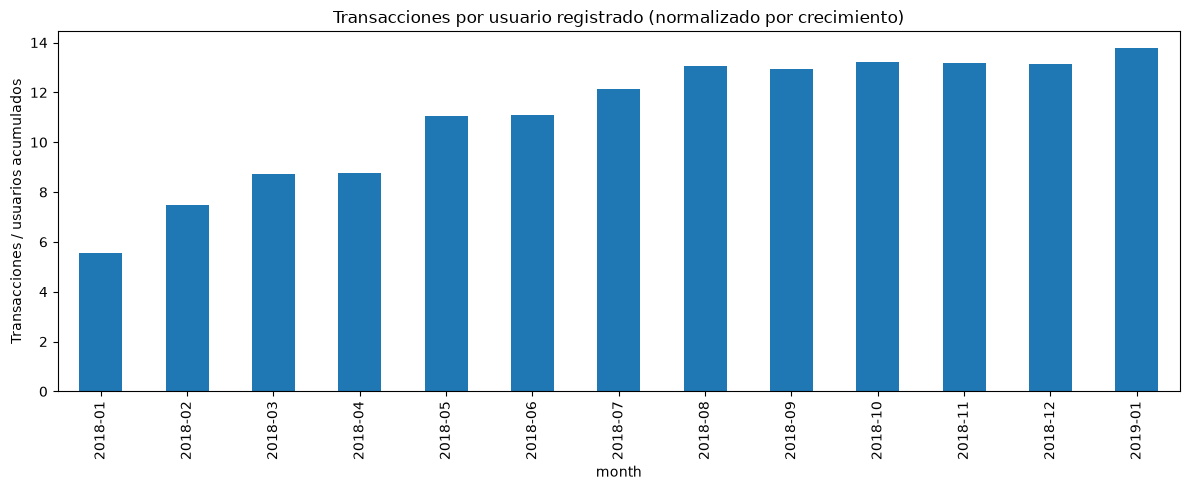

month
2018-01     5.568326
2018-02     7.475786
2018-03     8.710436
2018-04     8.759405
2018-05    11.048232
2018-06    11.109398
2018-07    12.148450
2018-08    13.043641
2018-09    12.930357
2018-10    13.238744
2018-11    13.187091
2018-12    13.133777
2019-01    13.762326
Freq: M, dtype: float64


In [17]:
# --- Método 1: transacciones por usuario registrado (normalizado por crecimiento) ---
signups_by_month = (
    clean_users_df
    .assign(month=lambda d: pd.to_datetime(d["created_date"]).dt.to_period("M"))
    .groupby("month")
    .size()
    .sort_index()
    .cumsum()
)

per_capita = (monthly_volume / signups_by_month.reindex(monthly_volume.index)).dropna()

plt.figure(figsize=(12, 5))
per_capita.plot(kind="bar")
plt.title("Transacciones por usuario registrado (normalizado por crecimiento)")
plt.ylabel("Transacciones / usuarios acumulados")
plt.tight_layout()
plt.show()

print(per_capita)

Tamaño de la cohorte fija: 2003 usuarios


/tmp/ipykernel_23044/579135957.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda d: d["created_date"].dt.to_period("M"))


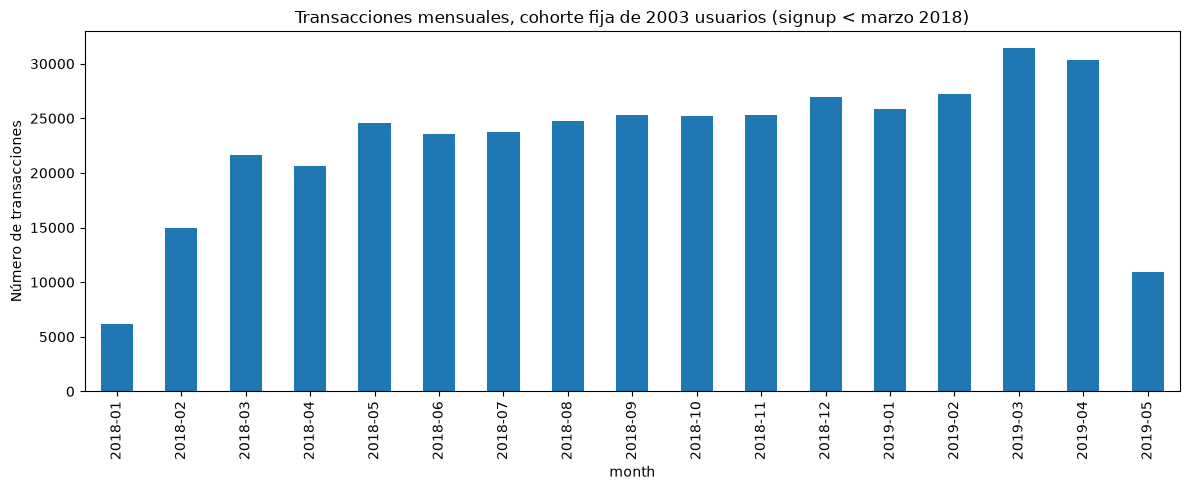

month
2018-01     6153
2018-02    14974
2018-03    21649
2018-04    20607
2018-05    24607
2018-06    23604
2018-07    23765
2018-08    24769
2018-09    25339
2018-10    25245
2018-11    25305
2018-12    26933
2019-01    25848
2019-02    27209
2019-03    31394
2019-04    30344
2019-05    10894
Freq: M, dtype: int64


In [18]:
# --- Método 2: cohorte fija (usuarios registrados antes de marzo 2018) ---
early_cohort_ids = clean_users_df.loc[
    pd.to_datetime(clean_users_df["created_date"]).dt.tz_localize(None) < pd.Timestamp("2018-03-01"),
    "user_id"
]
print(f"Tamaño de la cohorte fija: {len(early_cohort_ids)} usuarios")

cohort_monthly = (
    clean_transactions_df[clean_transactions_df["user_id"].isin(early_cohort_ids)]
    .assign(month=lambda d: d["created_date"].dt.to_period("M"))
    .groupby("month")
    .size()
)

plt.figure(figsize=(12, 5))
cohort_monthly.plot(kind="bar")
plt.title(f"Transacciones mensuales, cohorte fija de {len(early_cohort_ids)} usuarios (signup < marzo 2018)")
plt.ylabel("Número de transacciones")
plt.tight_layout()
plt.show()

print(cohort_monthly)

## Hipótesis de estacionalidad: no confirmada

Con dos métodos distintos (normalizado por crecimiento y cohorte fija sin
sesgo de tamaño de muestra) no encuentro evidencia de picos estacionales
en jun-ago (verano) ni dic-ene (invierno/fin de año). Lo que sí veo es una
curva de maduración: uso creciente en los primeros meses de cada usuario
que después se estabiliza, y un repunte en feb-abr 2019 que no coincide con
ningún patrón vacacional obvio -- probablemente algo puntual del negocio
(campaña, lanzamiento de feature) más que estacionalidad recurrente.

Limitación importante: solo tengo un verano y un invierno completos en la
ventana de datos -- no alcanzo a ver si el patrón se repetiría en un segundo
ciclo. No puedo descartar estacionalidad con solo una observación por
estación, pero tampoco tengo evidencia a favor.

Esto NO invalida el hallazgo de reactivación (21.94% de usuarios con hueco
>90 días que volvieron) -- solo significa que la causa probablemente no es
"vacaciones" específicamente. Puede ser cualquier motivo de pausa temporal
(viaje, cambio de trabajo, simplemente olvidarse de la app). El fix de
diseño de ventanas que ya propuse (medir resultado hasta el final de los
datos disponibles, no en una ventana corta fija) sigue siendo la decisión
correcta, independientemente de la causa específica de la pausa.

## Esquema de ventanas: observación (60 días) vs. resultado (hasta el final de los datos)

Divido la línea de tiempo de cada usuario en dos partes, ancladas a su
propio signup_date (no a una fecha de calendario fija, para que todos los
usuarios se comparen en el mismo punto relativo de su ciclo de vida):

- Ventana de OBSERVACIÓN: signup_date hasta signup_date + 60 días -> de aquí
  saco las features (cuánto transaccionó, cuántos días activo, etc.)
- Ventana de RESULTADO: desde el día 61 hasta REFERENCE_DATE (el final real
  de los datos, 2019-05-01) -> el label es "no tuvo ninguna transacción en
  toda esta ventana", sin importar cuánto duró (así respeto el hallazgo de
  reactivación: si volvió en cualquier momento antes del final de los datos,
  cuenta como activo).

Excluyo usuarios cuya ventana de resultado tenga menos de 60 días de
duración (es decir, signups muy tardíos, cerca de abril 2019) -- para ellos
no ha pasado suficiente tiempo para confiar en su label; son censurados por
la ventana de datos finita, no tengo forma de saber su desenlace todavía.
Documento cuántos usuarios se pierden por esto, para ser transparente sobre
el tamaño real de la muestra de entrenamiento.

In [19]:
OBSERVATION_WINDOW_DAYS = 60
MIN_OUTCOME_WINDOW_DAYS = 60  # mínimo de días de "resultado" para confiar en el label
REFERENCE_DATE = pd.Timestamp("2019-05-01")

users_base = clean_users_df.copy()
users_base["signup_date"] = pd.to_datetime(users_base["created_date"]).dt.tz_localize(None)
users_base["obs_end"] = users_base["signup_date"] + pd.Timedelta(days=OBSERVATION_WINDOW_DAYS)
users_base["outcome_window_days"] = (REFERENCE_DATE - users_base["obs_end"]).dt.days

# Excluyo usuarios sin suficiente ventana de resultado (censurados por datos finitos)
n_before = len(users_base)
model_users = users_base[users_base["outcome_window_days"] >= MIN_OUTCOME_WINDOW_DAYS].copy()
n_excluded = n_before - len(model_users)
print(f"Usuarios excluidos por ventana de resultado insuficiente: {n_excluded} de {n_before} "
      f"({n_excluded/n_before:.2%})")
print(f"Usuarios disponibles para el modelo: {len(model_users)}")

# --- Transacciones en la ventana de OBSERVACIÓN (primeros 60 días desde signup) ---
txn_tz_naive = clean_transactions_df.copy()
txn_tz_naive["created_date"] = txn_tz_naive["created_date"].dt.tz_localize(None)

txn_with_window = txn_tz_naive.merge(
    model_users[["user_id", "signup_date", "obs_end"]], on="user_id", how="inner"
)

obs_txns = txn_with_window[
    (txn_with_window["created_date"] >= txn_with_window["signup_date"]) &
    (txn_with_window["created_date"] < txn_with_window["obs_end"])
]

obs_features = (
    obs_txns
    .assign(is_declined=lambda d: d["transactions_state"] == "DECLINED",
            txn_date=lambda d: d["created_date"].dt.date)
    .groupby("user_id")
    .agg(
        num_transactions_obs=("transaction_id", "count"),
        total_amount_obs=("amount_usd", "sum"),
        avg_transaction_amount_obs=("amount_usd", "mean"),
        active_days_obs=("txn_date", "nunique"),
        declined_rate_obs=("is_declined", "mean"),
    )
    .reset_index()
)

# --- Transacciones en la ventana de RESULTADO (día 61 hasta REFERENCE_DATE) ---
# CORREGIDO: agrego el techo explícito en REFERENCE_DATE, que antes faltaba
# y dejaba que la ventana se extendiera hasta el final real de los datos (2019-05-16)
outcome_txns = txn_with_window[
    (txn_with_window["created_date"] >= txn_with_window["obs_end"]) &
    (txn_with_window["created_date"] <= REFERENCE_DATE)
]
users_active_in_outcome = set(outcome_txns["user_id"].unique())

model_users["churn_model"] = ~model_users["user_id"].isin(users_active_in_outcome)

# --- Ensamblo el dataset final: features de observación + variables estáticas + label ---
model_df = model_users.merge(obs_features, on="user_id", how="left")

# Usuarios sin NINGUNA transacción en la ventana de observación -> 0/NaN, no error
for col in ["num_transactions_obs", "total_amount_obs", "avg_transaction_amount_obs", "active_days_obs"]:
    model_df[col] = model_df[col].fillna(0)
model_df["declined_rate_obs"] = model_df["declined_rate_obs"].fillna(0)

model_df = model_df.merge(clean_devices_df, on="user_id", how="left")

print(f"\nShape final de model_df: {model_df.shape}")
print(f"Churn rate (nueva definición con ventanas): {model_df['churn_model'].mean():.2%}")
print(model_df["churn_model"].value_counts())

Usuarios excluidos por ventana de resultado insuficiente: 62 de 19430 (0.32%)
Usuarios disponibles para el modelo: 19368

Shape final de model_df: (19368, 21)
Churn rate (nueva definición con ventanas): 17.23%
churn_model
False    16030
True      3338
Name: count, dtype: int64


## Limitación: la ventana de resultado no tiene el mismo largo para todos

Un usuario que se registró en enero 2018 tiene ~15 meses de ventana de
resultado para "demostrar" que sigue activo; alguien que se registró en
enero 2019 solo tiene el mínimo de 60 días que exigí. Esto significa que
el label churn_model es más confiable para los usuarios más antiguos que
para los más nuevos -- un usuario reciente marcado como churned tiene más
probabilidad de ser un falso positivo (simplemente no le dio tiempo de
volver a transaccionar dentro de su ventana corta), mientras que uno
antiguo marcado como churned con 15 meses de oportunidad para volver es
una señal mucho más confiable.

Esto es exactamente el tipo de dato censurado de forma desigual que
Kaplan-Meier y Cox están diseñados para manejar de forma nativa (censura
por derecha, con distintos tiempos de seguimiento por sujeto) -- lo trato
como una limitación aceptada para Random Forest (un modelo de clasificación
binaria no tiene forma nativa de expresar "no estoy seguro, la ventana fue
corta"), y confío en que el análisis de supervivencia más adelante en el
proyecto corrija esta limitación de forma más rigurosa.

In [20]:
print("=" * 60)
print("MANN-WHITNEY U (features de ventana de OBSERVACIÓN, sin fuga)")
print("=" * 60)

for col in ["num_transactions_obs", "total_amount_obs", "avg_transaction_amount_obs",
            "active_days_obs", "declined_rate_obs"]:
    churned = model_df.loc[model_df["churn_model"], col].dropna()
    active = model_df.loc[~model_df["churn_model"], col].dropna()
    u_stat, p, r = rank_biserial(churned, active)
    print(f"\n{col}: U={u_stat:.1f}, p={p:.4f}, rank-biserial r={r:.4f}")
    print(f"  Mediana churned: {churned.median():.2f} | Mediana activos: {active.median():.2f}")

MANN-WHITNEY U (features de ventana de OBSERVACIÓN, sin fuga)

num_transactions_obs: U=12991494.5, p=0.0000, rank-biserial r=0.5144
  Mediana churned: 3.00 | Mediana activos: 14.00

total_amount_obs: U=14287470.5, p=0.0000, rank-biserial r=0.4660
  Mediana churned: 18.38 | Mediana activos: 445.72

avg_transaction_amount_obs: U=17632707.5, p=0.0000, rank-biserial r=0.3409
  Mediana churned: 5.96 | Mediana activos: 21.70

active_days_obs: U=12461468.0, p=0.0000, rank-biserial r=0.5342
  Mediana churned: 1.00 | Mediana activos: 7.00

declined_rate_obs: U=19201591.5, p=0.0000, rank-biserial r=0.2823
  Mediana churned: 0.00 | Mediana activos: 0.00


## Confirmando: la actividad temprana SÍ predice churn, sin fuga de información

Con las features acotadas a los primeros 60 días (sin tocar información
posterior al corte), num_transactions_obs (r=0.51) y active_days_obs
(r=0.53) siguen siendo las señales más fuertes -- pero ahora representan
algo real y accionable: un usuario que solo transacciona 3 veces en su
primer mes y medio, contra uno que transacciona 14, tiene una probabilidad
mucho mayor de abandonar después. Esto es información que el negocio SÍ
podría usar en tiempo real (ej. triggers de reactivación en los primeros
60 días para quien muestra baja actividad temprana), a diferencia del
hallazgo original que solo describía el desenlace ya ocurrido.

Noto que num_transactions_obs y active_days_obs probablemente estén muy
correlacionadas entre sí (ambas miden "qué tan activo estuvo" desde ángulos
distintos) -- esto no afecta el poder predictivo de Random Forest, pero sí
puede complicar la interpretación de SHAP más adelante si ambas compiten
por "crédito" de la misma señal. Lo reviso antes de entrenar el modelo.

declined_rate_obs tiene mediana 0.00 en ambos grupos (la mayoría de
usuarios no tiene ninguna transacción rechazada en 60 días), así que el
effect size de 0.28 debe venir de la cola de la distribución, no del centro
-- reviso el promedio y qué % tuvo al menos un rechazo, para entender mejor
qué está pasando ahí antes de sacar conclusiones.

In [21]:
# 1. Correlación entre las features de observación
obs_cols = ["num_transactions_obs", "total_amount_obs", "avg_transaction_amount_obs",
            "active_days_obs", "declined_rate_obs"]
print(model_df[obs_cols].corr().round(2))

                            num_transactions_obs  total_amount_obs  \
num_transactions_obs                        1.00              0.11   
total_amount_obs                            0.11              1.00   
avg_transaction_amount_obs                 -0.00              0.46   
active_days_obs                             0.88              0.10   
declined_rate_obs                           0.05              0.03   

                            avg_transaction_amount_obs  active_days_obs  \
num_transactions_obs                             -0.00             0.88   
total_amount_obs                                  0.46             0.10   
avg_transaction_amount_obs                        1.00            -0.00   
active_days_obs                                  -0.00             1.00   
declined_rate_obs                                 0.08             0.09   

                            declined_rate_obs  
num_transactions_obs                     0.05  
total_amount_obs                

In [22]:
# 2. declined_rate_obs: ¿qué pasa fuera de la mediana?
print("Promedio declined_rate_obs:")
print(model_df.groupby("churn_model")["declined_rate_obs"].mean())

print("\n% de usuarios con AL MENOS un rechazo en los primeros 60 días:")
print(model_df.assign(any_declined=lambda d: d["declined_rate_obs"] > 0)
      .groupby("churn_model")["any_declined"].mean())

Promedio declined_rate_obs:
churn_model
False    0.057047
True     0.033073
Name: declined_rate_obs, dtype: float64

% de usuarios con AL MENOS un rechazo en los primeros 60 días:
churn_model
False    0.487461
True     0.175554
Name: any_declined, dtype: float64


## Agregando notifications a la ventana de observación

Igual que con transactions, calculo estas métricas solo dentro de los
primeros 60 días desde signup de cada usuario, para mantener consistencia
con el resto del feature set y no reintroducir el problema de fuga que ya
corregimos. Failed_notification_rate es el candidato nuevo que vi en mi
estudio anterior (Mann-Whitney U con r=0.05 en esa versión -- chico, pero
lo confirmo aquí con mi propia metodología antes de decidir si lo incluyo).

In [23]:
# --- notifications dentro de la ventana de observación ---
notif_tz_naive = clean_notifications_df.copy()
notif_tz_naive["created_date"] = notif_tz_naive["created_date"].dt.tz_localize(None)

notif_with_window = notif_tz_naive.merge(
    model_users[["user_id", "signup_date", "obs_end"]], on="user_id", how="inner"
)

obs_notifs = notif_with_window[
    (notif_with_window["created_date"] >= notif_with_window["signup_date"]) &
    (notif_with_window["created_date"] < notif_with_window["obs_end"])
]

notif_features = (
    obs_notifs
    .assign(is_failed=lambda d: d["status"] != "SENT")  # ajustar valor exacto según categorías reales de status
    .groupby("user_id")
    .agg(
        num_notifications_obs=("reason", "count"),
        failed_notification_rate_obs=("is_failed", "mean"),
    )
    .reset_index()
)

print(clean_notifications_df["status"].value_counts())  # confirmar categorías reales antes de asumir "SENT"

status
SENT      89477
FAILED    32336
Name: count, dtype: int64


In [24]:
notif_features = (
    obs_notifs
    .assign(is_failed=lambda d: d["status"] == "FAILED")
    .groupby("user_id")
    .agg(
        num_notifications_obs=("reason", "count"),
        failed_notification_rate_obs=("is_failed", "mean"),
    )
    .reset_index()
)

print(notif_features.describe())

       num_notifications_obs  failed_notification_rate_obs
count           13295.000000                  13295.000000
mean                3.231516                      0.193804
std                 2.466465                      0.304608
min                 1.000000                      0.000000
25%                 2.000000                      0.000000
50%                 3.000000                      0.000000
75%                 4.000000                      0.333333
max                43.000000                      1.000000


## Variables adicionales de transactions: diversidad de comercio y geografía

Agrego num_merchant_categories_obs (cuántas categorías de comercio distintas
usó, solo aplica a transacciones con merchant) y num_countries_visited_obs
(en cuántos países distintos transaccionó -- señal de movilidad/viaje, que
podría capturar parte de lo que sospechaba sobre uso en el extranjero).
También separo out_count/in_count por dirección, ya que en el estudio de
referencia salieron como el driver dominante -- quiero confirmar si sigue
siendo así una vez acotado a la ventana de observación de 60 días, sin la
fuga que sospecho que tenía ese estudio anterior.

In [25]:
obs_txns_extra = (
    obs_txns
    .groupby("user_id")
    .agg(
        num_merchant_categories_obs=("ea_merchant_country", lambda s: s[s != "NOT_APPLICABLE"].nunique()),
        num_countries_visited_obs=("ea_merchant_country", lambda s: s[s != "NOT_APPLICABLE"].nunique()),
    )
    .reset_index()
)

direction_counts = (
    obs_txns
    .groupby(["user_id", "direction"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={"OUTBOUND": "out_count_obs", "INBOUND": "in_count_obs"})
)

print(obs_txns_extra.describe())
print(direction_counts.head())

       num_merchant_categories_obs  num_countries_visited_obs
count                 17476.000000               17476.000000
mean                      1.522717                   1.522717
std                       1.633588                   1.633588
min                       0.000000                   0.000000
25%                       0.000000                   0.000000
50%                       1.000000                   1.000000
75%                       2.000000                   2.000000
max                      18.000000                  18.000000
direction    user_id  in_count_obs  out_count_obs
0             user_0            15             57
1             user_1             1             11
2            user_10            41             61
3           user_100             2             10
4          user_1000            12             19


In [26]:
obs_txns_extra = (
    obs_txns
    .groupby("user_id")
    .agg(
        num_merchant_categories_obs=("ea_merchant_mcc", lambda s: s[s != "NOT_APPLICABLE"].nunique()),
        num_countries_visited_obs=("ea_merchant_country", lambda s: s[s != "NOT_APPLICABLE"].nunique()),
    )
    .reset_index()
)

print(obs_txns_extra.describe())

       num_merchant_categories_obs  num_countries_visited_obs
count                 17476.000000               17476.000000
mean                      5.086519                   1.522717
std                       6.368184                   1.633588
min                       0.000000                   0.000000
25%                       0.000000                   0.000000
50%                       2.000000                   1.000000
75%                       8.000000                   2.000000
max                      50.000000                  18.000000


## Ensamblando el dataset final con las ~22 variables

Uno todas las piezas que construí en este notebook: las variables estáticas
de users (age, plan, country, num_contacts, etc.), device_brand, las
features de transactions en la ventana de observación (actividad, montos,
diversidad de comercio/país, in/out count), y las nuevas de notifications
(volumen y tasa de fallo). Todo queda a nivel de un renglón por usuario,
con churn_model como variable objetivo, listo para las pruebas estadísticas
completas en el siguiente notebook.

Los NaN que quedan después de estos merges representan usuarios sin
actividad de ese tipo en la ventana de observación (ej. nunca recibió una
notificación, o nunca hizo una transacción con comercio) -- los relleno con
0, ya que "cero eventos" es la interpretación correcta, no un dato perdido.

In [27]:
model_df_full = (
    model_df
    .merge(notif_features, on="user_id", how="left")
    .merge(obs_txns_extra, on="user_id", how="left")
    .merge(direction_counts[["user_id", "in_count_obs", "out_count_obs"]], on="user_id", how="left")
)

fill_zero_cols = [
    "num_notifications_obs", "failed_notification_rate_obs",
    "num_merchant_categories_obs", "num_countries_visited_obs",
    "in_count_obs", "out_count_obs",
]
for col in fill_zero_cols:
    model_df_full[col] = model_df_full[col].fillna(0)

print(f"Shape final: {model_df_full.shape}")
print(f"Columnas: {model_df_full.columns.tolist()}")
print(f"\nNulls restantes por columna:")
print(model_df_full.isna().sum()[model_df_full.isna().sum() > 0])

Shape final: (19368, 27)
Columnas: ['user_id', 'birth_year', 'country', 'city', 'created_date', 'user_settings_crypto_unlocked', 'plan', 'attributes_notifications_marketing_push', 'attributes_notifications_marketing_email', 'num_contacts', 'age', 'signup_date', 'obs_end', 'outcome_window_days', 'churn_model', 'num_transactions_obs', 'total_amount_obs', 'avg_transaction_amount_obs', 'active_days_obs', 'declined_rate_obs', 'device_brand', 'num_notifications_obs', 'failed_notification_rate_obs', 'num_merchant_categories_obs', 'num_countries_visited_obs', 'in_count_obs', 'out_count_obs']

Nulls restantes por columna:
Series([], dtype: int64)


In [38]:
model_df_full.to_parquet("../data/model_df_full.parquet", index=False)
print("Guardado en ../data/model_df_full.parquet")

Guardado en ../data/model_df_full.parquet


In [29]:
# Aplicando el techo correcto de REFERENCE_DATE
outcome_txns_corrected = txn_with_window[
    (txn_with_window["created_date"] >= txn_with_window["obs_end"]) &
    (txn_with_window["created_date"] <= REFERENCE_DATE)
]
users_active_in_outcome_corrected = set(outcome_txns_corrected["user_id"].unique())

model_df["churn_model_corrected"] = ~model_df["user_id"].isin(users_active_in_outcome_corrected)

n_flipped = (model_df["churn_model"] != model_df["churn_model_corrected"]).sum()
print(f"Etiquetas que cambian: {n_flipped} de {len(model_df)} ({n_flipped/len(model_df):.2%})")
print(f"\nChurn rate actual (con bug): {model_df['churn_model'].mean():.2%}")
print(f"Churn rate corregido: {model_df['churn_model_corrected'].mean():.2%}")

Etiquetas que cambian: 0 de 19368 (0.00%)

Churn rate actual (con bug): 17.23%
Churn rate corregido: 17.23%


In [30]:
print(f"\nShape final de model_df: {model_df.shape}")
print(f"Churn rate (nueva definición con ventanas): {model_df['churn_model'].mean():.2%}")


Shape final de model_df: (19368, 22)
Churn rate (nueva definición con ventanas): 17.23%


In [36]:
import os
from datetime import datetime
print(datetime.fromtimestamp(os.path.getmtime("../data/model_df_final_features.parquet")))

2026-07-13 18:28:14.931572


In [37]:
import os
print("Directorio de trabajo actual:", os.getcwd())
print("Ruta absoluta donde se guardaría:", os.path.abspath("../data/model_df_final_features.parquet"))

Directorio de trabajo actual: /home/itzelosalamandra/code/ItzeloSalamandra/neobank-churn-survival-analysis/notebooks
Ruta absoluta donde se guardaría: /home/itzelosalamandra/code/ItzeloSalamandra/neobank-churn-survival-analysis/data/model_df_final_features.parquet


In [39]:
import os
from datetime import datetime
print(datetime.fromtimestamp(os.path.getmtime("../data/model_df_final_features.parquet")))

2026-07-13 18:28:14.931572


In [40]:
# 1. Verifica el churn rate de la variable en memoria AHORA MISMO
print(f"Churn rate de model_df_full en memoria: {model_df_full['churn_model'].mean():.2%}")

# 2. Guarda
model_df_full.to_parquet("../data/model_df_full.parquet", index=False)
print("Comando to_parquet ejecutado sin error")

# 3. Verifica con el sistema operativo directamente (no solo Python)

Churn rate de model_df_full en memoria: 17.23%
Comando to_parquet ejecutado sin error
